In [ ]:
# ── repo path bootstrap ───────────────────────────────────────────────────────
# REORGANISATION_FIX_PLAN.md 5.8.  The modules are flat but live in
# Transformer_model/ and Experimental_setup/, and this notebook sits in
# Jupyter_notebooks/, so the cwd alone is not enough.  Walk up to the .git marker,
# chdir there so repo-relative data paths resolve as they did before the tree was
# reorganised, and put both source directories on sys.path.
# Idempotent -- safe to re-run this cell.
import os, sys
_p = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_p, ".git")) and _p != os.path.dirname(_p):
    _p = os.path.dirname(_p)
ROOT = _p
os.chdir(ROOT)
for _d in ("Transformer_model", "Experimental_setup"):
    if os.path.join(ROOT, _d) not in sys.path:
        sys.path.insert(0, os.path.join(ROOT, _d))
print("repo root:", ROOT)


# Causal-asymmetry metric panel — Metric 0 (PPL) + Metrics 1–3 (bits)

Reproduces the asymmetry figure but in the clean form: **Metric 0 (standard PPL)** in its
own panel (informational only), and **Metrics 1, 2, 3 together** on a shared bit axis.

This notebook *reuses the tooling already implemented in the repo* — it does not reimplement
any metric. It only adds a new plotting cell. Mapping:

| Metric | Reused function | Unit |
|---|---|---|
| 0 — standard PPL (informational) | `compute_standard_ppl` → `perplexity_ind_model` | perplexity |
| 1 — hard-label CE (primary)      | `compute_ce` → `perplexity_calculation`         | bits |
| 2 — soft-label CE                | `compute_ind_ce` → `perplexity_ind_CE`          | bits |
| 3 — mean stepwise KL             | `stepwise_kl_coin`                              | bits |
| H∞ — entropy-rate floor          | `entropy_rate_coin`                             | bits |

**Where to run it:** place this notebook in the repo root (`LLM_final_version/`) so the
project modules import and `results/models/` is visible. Metrics 2 and 3 are coin-only
(the flower process has no closed-form conditional), so this panel targets the coin experiments.


In [3]:
import os
import numpy as np
import torch
import matplotlib

# Reuse the project's implemented tooling.
# NOTE: importing LLM_asymmetry_testing runs matplotlib.use("Agg") and sets usetex=True
# at import time; we override both right after so figures render inline.
from LLM_asymmetry_testing import (
    load_model,            # build OneHotDecoder + load .pt weights
    entropy_rate_coin,     # H_inf for the coin process
    stepwise_kl_coin,      # Metric 3
    compute_standard_ppl,  # Metric 0  -> perplexity_ind_model
    compute_ce,            # Metric 1  -> perplexity_calculation
    compute_ind_ce,        # Metric 2  -> perplexity_ind_CE
    CFG,                   # default config (d_model, max_len, n_layers, max_batches, ...)
)
from Data_generation import CoinDataset, coin_generation
from Training_model import _loader

import matplotlib.pyplot as plt

# Flip USETEX to True to match the paper's Computer Modern font (needs a working LaTeX install).
# All plot strings below are mathtext-compatible, so they render in either mode.
USETEX = False
plt.rcParams.update({
    "text.usetex": USETEX,
    "font.family": "serif",
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "figure.dpi": 120,
})
print("torch", torch.__version__, "| cwd:", os.getcwd())

UMAP unavailable (No module named 'umap') — PCA fallback active
torch 2.12.1 | cwd: /Users/tisornnaphattalung/Desktop/Quantum/URECA/LLM_final_version


In [4]:
# ---- paths & experiment registry ------------------------------------------
MODELS_DIR = "results/models"
OUT_DIR    = "results/asymmetry_test"     # figures saved here, per experiment

# Coin experiments that have trained FW/BW weights in results/models/.
# (p, q) must match the values the models were trained with.
COIN_EXPERIMENTS = {
    "exp1_coin_p03_q04":   dict(p=0.3, q=0.4),
    "exp1_2_coin_p04_q08": dict(p=0.4, q=0.8),
    "exp1_2_coin_p01_q09": dict(p=0.1, q=0.9),
}

# Evaluation data scale (matches LLM_asymmetry_testing defaults).
# Reduce num_samples / set MAX_BATCHES for a quick preview; Metric 3 is the slow one.
NUM_SAMPLES = 500
SEQ_LEN     = 2000
BATCH_SIZE  = 32
NUM_TOKEN   = 3
MAX_BATCHES = CFG.get("max_batches")   # None = use all batches

TAG = "exp1_coin_p03_q04"              # <-- choose which experiment to plot
print("available:", list(COIN_EXPERIMENTS))

available: ['exp1_coin_p03_q04', 'exp1_2_coin_p04_q08', 'exp1_2_coin_p01_q09']


In [5]:
def compute_all_metrics(tag, p, q, *, seq_len=SEQ_LEN, num_samples=NUM_SAMPLES,
                        batch_size=BATCH_SIZE, num_token=NUM_TOKEN,
                        max_batches=MAX_BATCHES, models_dir=MODELS_DIR, cfg=CFG):
    """
    Load FW/BW models for `tag` and compute all four metrics + H_inf on a freshly
    generated ground-truth coin loader. Mirrors the computation block of eval_coin,
    reusing the imported functions (no metric is reimplemented here).
    """
    fw_path = os.path.join(models_dir, f"{tag}_fw.pt")
    bw_path = os.path.join(models_dir, f"{tag}_bw.pt")
    for pth in (fw_path, bw_path):
        if not os.path.exists(pth):
            raise FileNotFoundError(pth)

    model_fw = load_model(fw_path, num_token, cfg, mode="forward")
    model_bw = load_model(bw_path, num_token, cfg, mode="backward")

    # Same ground-truth loader for both models (the principled comparison).
    data, _ = coin_generation(num_samples=num_samples, seq_len=seq_len, p=p, q=q)
    loader  = _loader(CoinDataset(data, seq_len=seq_len), batch_size)

    h_inf = entropy_rate_coin(p, q)

    # Metric 0 — standard autoregressive PPL on each model's own sequence (informational)
    ppl0_fw = compute_standard_ppl(model_fw, len_seq=seq_len)
    ppl0_bw = compute_standard_ppl(model_bw, len_seq=seq_len)

    # Metric 1 — hard-label CE on the ground-truth loader (primary signal)
    _, ce1_fw = compute_ce(model_fw, loader, max_batches)
    _, ce1_bw = compute_ce(model_bw, loader, max_batches)

    # Metric 2 — soft-label CE vs the analytic HMM conditional (ground-truth loader)
    _, ce2_fw = compute_ind_ce(model_fw, loader, p, q, cfg)
    _, ce2_bw = compute_ind_ce(model_bw, loader, p, q, cfg)

    # Metric 3 — mean stepwise KL on the ground-truth loader
    kl3_fw, _, _ = stepwise_kl_coin(model_fw, loader, p, q, num_token, max_batches)
    kl3_bw, _, _ = stepwise_kl_coin(model_bw, loader, p, q, num_token, max_batches)

    return dict(tag=tag, p=p, q=q, h_inf=h_inf,
                ppl0_fw=ppl0_fw, ppl0_bw=ppl0_bw,
                ce1_fw=ce1_fw,   ce1_bw=ce1_bw,
                ce2_fw=ce2_fw,   ce2_bw=ce2_bw,
                kl3_fw=kl3_fw,   kl3_bw=kl3_bw)


def print_summary(M):
    d1 = M["ce1_bw"] - M["ce1_fw"]
    d2 = M["ce2_bw"] - M["ce2_fw"]
    d3 = M["kl3_bw"] - M["kl3_fw"]
    print(f"=== {M['tag']}  (p={M['p']}, q={M['q']}) ===")
    print(f"H_inf (entropy-rate floor)      = {M['h_inf']:.4f} bits\n")
    print(f"[M0] standard PPL    FW / BW    = {M['ppl0_fw']:.4f} / {M['ppl0_bw']:.4f}  (informational)")
    print(f"[M1] hard-label CE   FW / BW    = {M['ce1_fw']:.4f} / {M['ce1_bw']:.4f} bits   d = {d1:+.4f}")
    print(f"[M2] soft-label CE   FW / BW    = {M['ce2_fw']:.4f} / {M['ce2_bw']:.4f} bits   d = {d2:+.4f}")
    print(f"[M3] mean KL         FW / BW    = {M['kl3_fw']:.4f} / {M['kl3_bw']:.4f} bits   d = {d3:+.4f}\n")
    print("consistency checks:")
    print(f"  M1 ~= M2 ?            FW: {M['ce1_fw']:.4f} vs {M['ce2_fw']:.4f}"
          f"   BW: {M['ce1_bw']:.4f} vs {M['ce2_bw']:.4f}")
    print(f"  M2 ~= H_inf + M3 ?    FW: {M['ce2_fw']:.4f} vs {M['h_inf']+M['kl3_fw']:.4f}"
          f"   BW: {M['ce2_bw']:.4f} vs {M['h_inf']+M['kl3_bw']:.4f}")

In [6]:
params = COIN_EXPERIMENTS[TAG]
M = compute_all_metrics(TAG, params["p"], params["q"])
print_summary(M)

  loaded results/models/exp1_coin_p03_q04_fw.pt  [forward]
  loaded results/models/exp1_coin_p03_q04_bw.pt  [backward]
Standard PPL over 1900 tokens (burn-in=100) ...
Standard PPL over 1900 tokens (burn-in=100) ...
    mean KL = 0.214134 bits
      token 0: avg KL=0.018534  (n=399132)
      token 1: avg KL=0.474398  (n=428683)
      token 2: avg KL=0.019004  (n=171685)
    mean KL = 1.056852 bits
      token 0: avg KL=0.688200  (n=399159)
      token 1: avg KL=1.823377  (n=428666)
      token 2: avg KL=0.000016  (n=171675)
=== exp1_coin_p03_q04  (p=0.3, q=0.4) ===
H_inf (entropy-rate floor)      = 0.9197 bits

[M0] standard PPL    FW / BW    = 1.8798 / 1.9013  (informational)
[M1] hard-label CE   FW / BW    = 1.1345 / 1.9792 bits   d = +0.8447
[M2] soft-label CE   FW / BW    = 1.1339 / 1.9764 bits   d = +0.8425
[M3] mean KL         FW / BW    = 0.2141 / 1.0569 bits   d = +0.8427

consistency checks:
  M1 ~= M2 ?            FW: 1.1345 vs 1.1339   BW: 1.9792 vs 1.9764
  M2 ~= H_inf + M3 

In [7]:
FW_C, BW_C = "#4c72b0", "#dd8452"
FW_LBL, BW_LBL = r"$\leftarrow$ Forward", r"Backward $\rightarrow$"


def plot_metric_panel(M, out_path=None, usetex=None):
    """1x2 figure: Metric 0 (PPL, informational) | Metrics 1-3 (bits, asymmetry signal)."""
    if usetex is None:
        usetex = plt.rcParams["text.usetex"]
    tag_disp = M["tag"].replace("_", r"\_") if usetex else M["tag"]

    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1.0, 2.2]})

    # ---- LEFT: Metric 0 — standard PPL (informational) ----------------------
    v0 = [M["ppl0_fw"], M["ppl0_bw"]]
    b0 = axL.bar([FW_LBL, BW_LBL], v0, color=[FW_C, BW_C],
                 alpha=0.85, edgecolor="k", width=0.5)
    axL.bar_label(b0, fmt="%.4f", padding=3, fontsize=9)
    href = 2 ** M["h_inf"]
    axL.axhline(href, color="crimson", ls="--", lw=1.5,
                label=rf"$2^{{H_\infty}} = {href:.4f}$")
    axL.legend(fontsize=8, loc="lower right")
    axL.set_ylabel(r"Perplexity $2^{\mathcal{L}}$")
    axL.set_ylim(0, max(v0 + [href]) * 1.18)
    axL.set_title(r"\textit{Metric 0}: standard PPL (informational)" if usetex
                  else "Metric 0: standard PPL (informational)")
    axL.grid(True, alpha=0.3, axis="y")
    axL.text(0.5, 0.94, rf"$\Delta = {v0[1]-v0[0]:+.4f}$",
             transform=axL.transAxes, ha="center", fontsize=9)

    # ---- RIGHT: Metrics 1, 2, 3 — bits --------------------------------------
    groups = ["Metric 1\n(hard-label CE)", "Metric 2\n(soft-label CE)", "Metric 3\n(mean KL)"]
    fw = [M["ce1_fw"], M["ce2_fw"], M["kl3_fw"]]
    bw = [M["ce1_bw"], M["ce2_bw"], M["kl3_bw"]]
    x, w = np.arange(3), 0.38
    bF = axR.bar(x - w/2, fw, w, color=FW_C, alpha=0.85, edgecolor="k", label=FW_LBL)
    bB = axR.bar(x + w/2, bw, w, color=BW_C, alpha=0.85, edgecolor="k", label=BW_LBL)
    axR.bar_label(bF, fmt="%.3f", padding=2, fontsize=8)
    axR.bar_label(bB, fmt="%.3f", padding=2, fontsize=8)
    axR.axhline(M["h_inf"], color="crimson", ls="--", lw=1.5,
                label=rf"$H_\infty = {M['h_inf']:.4f}$ (floor: M1, M2)")
    top = max(fw + bw)
    for xi, (f, b) in enumerate(zip(fw, bw)):
        axR.text(xi, max(f, b) + 0.06 * top, rf"$\Delta = {b-f:+.3f}$",
                 ha="center", fontsize=8)
    axR.set_xticks(x); axR.set_xticklabels(groups, fontsize=9)
    axR.set_ylabel("bits / token")
    axR.set_ylim(0, top * 1.28)
    axR.set_title(r"\textit{Metrics 1--3}: asymmetry signal (bits)" if usetex
                  else "Metrics 1-3: asymmetry signal (bits)")
    axR.legend(fontsize=8, loc="upper left", ncol=1)
    axR.grid(True, alpha=0.3, axis="y")

    suptitle = (rf"\textbf{{{tag_disp}}} --- causal asymmetry "
                r"($\mathcal{L}_\mathrm{BW} - \mathcal{L}_\mathrm{FW}$)") if usetex else \
               (rf"{tag_disp} — causal asymmetry "
                r"($\mathcal{L}_\mathrm{BW} - \mathcal{L}_\mathrm{FW}$)")
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print("saved:", out_path)
    plt.show()
    return fig

In [8]:
out_path = os.path.join(OUT_DIR, TAG, f"{TAG}_metric_panel.png")
_ = plot_metric_panel(M, out_path=out_path)

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


saved: results/asymmetry_test/exp1_coin_p03_q04/exp1_coin_p03_q04_metric_panel.png


/var/folders/cn/1yhq64td3_j1p23cdwjs4xsh0000gn/T/ipykernel_36356/2893152340.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Batch: every coin experiment

Loops over all coin experiments with trained weights and writes one panel each.
Skips any experiment whose `.pt` files are not present in `results/models/`.


In [9]:
all_metrics = {}
for tag, prm in COIN_EXPERIMENTS.items():
    try:
        Mi = compute_all_metrics(tag, prm["p"], prm["q"])
    except FileNotFoundError as e:
        print(f"skip {tag}: missing weights ({e})")
        continue
    all_metrics[tag] = Mi
    print_summary(Mi)
    plot_metric_panel(Mi, out_path=os.path.join(OUT_DIR, tag, f"{tag}_metric_panel.png"))
    print()

  loaded results/models/exp1_coin_p03_q04_fw.pt  [forward]
  loaded results/models/exp1_coin_p03_q04_bw.pt  [backward]
Standard PPL over 1900 tokens (burn-in=100) ...
Standard PPL over 1900 tokens (burn-in=100) ...
    mean KL = 0.215402 bits
      token 0: avg KL=0.018641  (n=399662)
      token 1: avg KL=0.477098  (n=428858)
      token 2: avg KL=0.018932  (n=170980)


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

    mean KL = 1.061631 bits
      token 0: avg KL=0.693851  (n=399685)
      token 1: avg KL=1.827584  (n=428859)
      token 2: avg KL=0.000017  (n=170956)
=== exp1_coin_p03_q04  (p=0.3, q=0.4) ===
H_inf (entropy-rate floor)      = 0.9197 bits

[M0] standard PPL    FW / BW    = 1.8604 / 1.9168  (informational)
[M1] hard-label CE   FW / BW    = 1.1333 / 1.9771 bits   d = +0.8438
[M2] soft-label CE   FW / BW    = 1.1352 / 1.9819 bits   d = +0.8467
[M3] mean KL         FW / BW    = 0.2154 / 1.0616 bits   d = +0.8462

consistency checks:
  M1 ~= M2 ?            FW: 1.1333 vs 1.1352   BW: 1.9771 vs 1.9819
  M2 ~= H_inf + M3 ?    FW: 1.1352 vs 1.1351   BW: 1.9819 vs 1.9813


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

saved: results/asymmetry_test/exp1_coin_p03_q04/exp1_coin_p03_q04_metric_panel.png

  loaded results/models/exp1_2_coin_p04_q08_fw.pt  [forward]
  loaded results/models/exp1_2_coin_p04_q08_bw.pt  [backward]
Standard PPL over 1900 tokens (burn-in=100) ...
Standard PPL over 1900 tokens (burn-in=100) ...
    mean KL = 0.267285 bits
      token 0: avg KL=0.018099  (n=398509)
      token 1: avg KL=0.760852  (n=333865)
      token 2: avg KL=0.022150  (n=267126)


...

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

    mean KL = 0.120488 bits
      token 0: avg KL=0.009773  (n=809417)
      token 1: avg KL=0.367546  (n=100034)
      token 2: avg KL=0.841209  (n=90049)
=== exp1_2_coin_p01_q09  (p=0.1, q=0.9) ===
H_inf (entropy-rate floor)      = 0.4690 bits

[M0] standard PPL    FW / BW    = 1.5620 / 1.0898  (informational)
[M1] hard-label CE   FW / BW    = 0.6546 / 0.5876 bits   d = -0.0670
[M2] soft-label CE   FW / BW    = 0.6546 / 0.5895 bits   d = -0.0651
[M3] mean KL         FW / BW    = 0.1856 / 0.1205 bits   d = -0.0651

consistency checks:
  M1 ~= M2 ?            FW: 0.6546 vs 0.6546   BW: 0.5876 vs 0.5895
  M2 ~= H_inf + M3 ?    FW: 0.6546 vs 0.6546   BW: 0.5895 vs 0.5895


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

saved: results/asymmetry_test/exp1_2_coin_p01_q09/exp1_2_coin_p01_q09_metric_panel.png



/var/folders/cn/1yhq64td3_j1p23cdwjs4xsh0000gn/T/ipykernel_36356/2893152340.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  loaded results/models/exp2_flower_n6_m4_fw.pt  [forward]
  loaded results/models/exp2_flower_n6_m4_bw.pt  [backward]


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

=== exp2_flower_n6_m4  (n=6, m=4) ===
[M1] hard-label CE   FW / BW = 3.3307 / 3.2361 bits
delta = BW - FW = -0.0946


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

saved: results/asymmetry_test/exp2_flower_n6_m4/exp2_flower_n6_m4_ce_histogram.png


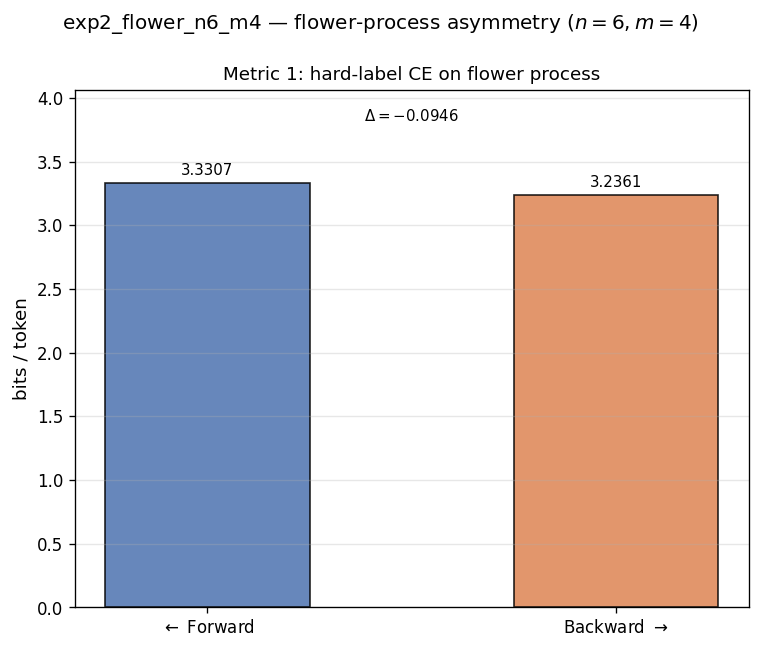

In [13]:


import os
import numpy as np
import matplotlib.pyplot as plt

from LLM_asymmetry_testing import (
    load_model,
    compute_ce,
    CFG,
)

from Data_generation import flower_process_generation
from Flower_process_generation import FlowerDataset
from Training_model import _loader


# ---------------------------------------------------------------------
# Same plotting format / colors as the existing metric-panel figure
# ---------------------------------------------------------------------

FW_C, BW_C = "#4c72b0", "#dd8452"
FW_LBL, BW_LBL = r"$\leftarrow$ Forward", r"Backward $\rightarrow$"

MODELS_DIR = "results/models"
OUT_DIR = "results/asymmetry_test"


# ---------------------------------------------------------------------
# Flower experiment: n = 6, m = 4
# Models from screenshot:
#   exp2_flower_n6_m4_fw.pt
#   exp2_flower_n6_m4_bw.pt
# ---------------------------------------------------------------------

FLOWER_TAG = "exp2_flower_n6_m4"

FLOWER_N = 6
FLOWER_M = 4
FLOWER_NUM_TOKEN = FLOWER_N + FLOWER_M

FLOWER_NUM_SAMPLES = CFG.get("num_samples", 500)
FLOWER_SEQ_LEN = CFG.get("flower_seq_len", 2000)
FLOWER_BATCH_SIZE = CFG.get("batch_size", 32)
FLOWER_MAX_BATCHES = CFG.get("max_batches", None)


# ---------------------------------------------------------------------
# Compute hard-label CE on the same flower-process test loader
# ---------------------------------------------------------------------

def compute_flower_ce(
    tag=FLOWER_TAG,
    n=FLOWER_N,
    m=FLOWER_M,
    num_samples=FLOWER_NUM_SAMPLES,
    seq_len=FLOWER_SEQ_LEN,
    batch_size=FLOWER_BATCH_SIZE,
    max_batches=FLOWER_MAX_BATCHES,
    models_dir=MODELS_DIR,
    cfg=CFG,
):
    fw_path = os.path.join(models_dir, f"{tag}_fw.pt")
    bw_path = os.path.join(models_dir, f"{tag}_bw.pt")

    for path in [fw_path, bw_path]:
        if not os.path.exists(path):
            raise FileNotFoundError(path)

    num_token = n + m

    model_fw = load_model(
        fw_path,
        num_token,
        cfg,
        mode="forward",
    )

    model_bw = load_model(
        bw_path,
        num_token,
        cfg,
        mode="backward",
    )

    # Same convention as the project evaluation code:
    # fixed fresh flower data for a fair FW/BW comparison.
    rng = np.random.default_rng(99)
    dice_probs = rng.dirichlet(np.ones(m), size=n)

    data, _ = flower_process_generation(
        num_samples=num_samples,
        seq_len=seq_len,
        n=n,
        m=m,
        dice_probs=dice_probs,
    )

    seq_len_f = len(data[0])
    ds = FlowerDataset(data, seq_len=seq_len_f)
    loader = _loader(ds, batch_size)

    # Metric 1 — hard-label CE
    _, ce1_fw = compute_ce(model_fw, loader, max_batches)
    _, ce1_bw = compute_ce(model_bw, loader, max_batches)

    return {
        "tag": tag,
        "n": n,
        "m": m,
        "num_token": num_token,
        "ce1_fw": ce1_fw,
        "ce1_bw": ce1_bw,
        "delta": ce1_bw - ce1_fw,
    }


# ---------------------------------------------------------------------
# Plot CE histogram / bar plot using same style as metric_panel_plot
# ---------------------------------------------------------------------

def plot_flower_ce_histogram(M, out_path=None, usetex=None):
    if usetex is None:
        usetex = plt.rcParams.get("text.usetex", False)

    tag_disp = M["tag"].replace("_", r"\_") if usetex else M["tag"]

    vals = [M["ce1_fw"], M["ce1_bw"]]
    labels = [FW_LBL, BW_LBL]
    colors = [FW_C, BW_C]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))

    bars = ax.bar(
        labels,
        vals,
        color=colors,
        alpha=0.85,
        edgecolor="k",
        width=0.5,
    )

    ax.bar_label(
        bars,
        fmt="%.4f",
        padding=3,
        fontsize=9,
    )

    top = max(vals)
    ax.text(
        0.5,
        0.94,
        rf"$\Delta = {M['delta']:+.4f}$",
        transform=ax.transAxes,
        ha="center",
        fontsize=9,
    )

    ax.set_ylabel("bits / token")
    ax.set_ylim(0, top * 1.22)
    ax.grid(True, alpha=0.3, axis="y")

    ax.set_title(
        r"\textit{Metric 1}: hard-label CE on flower process"
        if usetex
        else "Metric 1: hard-label CE on flower process"
    )

    suptitle = (
        rf"\textbf{{{tag_disp}}} --- flower-process asymmetry "
        rf"($n={M['n']}, m={M['m']}$)"
        if usetex
        else
        rf"{tag_disp} — flower-process asymmetry "
        rf"($n={M['n']}, m={M['m']}$)"
    )

    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print("saved:", out_path)

    plt.show()
    return fig


# ---------------------------------------------------------------------
# Run and save
# ---------------------------------------------------------------------

M_flower = compute_flower_ce()

print(f"=== {M_flower['tag']}  (n={M_flower['n']}, m={M_flower['m']}) ===")
print(f"[M1] hard-label CE   FW / BW = {M_flower['ce1_fw']:.4f} / {M_flower['ce1_bw']:.4f} bits")
print(f"delta = BW - FW = {M_flower['delta']:+.4f}")

flower_out_path = os.path.join(
    OUT_DIR,
    FLOWER_TAG,
    f"{FLOWER_TAG}_ce_histogram.png",
)

_ = plot_flower_ce_histogram(
    M_flower,
    out_path=flower_out_path,
)